In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [2]:
users = pd.read_csv('/Users/admin/Desktop/RecSys/KION_DATASET/data_original/users.csv')
items = pd.read_csv('/Users/admin/Desktop/RecSys/KION_DATASET/data_original/items.csv')
interactions = pd.read_csv('/Users/admin/Desktop/RecSys/KION_DATASET/interactions.csv')

In [3]:
interactions.head()

,user_id,item_id,last_watch_dt,total_dur,watched_pct
0,176549,9506,2021-05-11,4250.0,72.0
1,699317,1659,2021-05-29,8317.0,100.0
2,656683,7107,2021-05-09,10.0,0.0
3,864613,7638,2021-07-05,14483.0,100.0
4,964868,9506,2021-04-30,6725.0,100.0


In [4]:
users.head()

,user_id,age,income,sex,kids_flg
0,973171,age_25_34,income_60_90,М,1
1,962099,age_18_24,income_20_40,М,0
2,1047345,age_45_54,income_40_60,Ж,0
3,721985,age_45_54,income_20_40,Ж,0
4,704055,age_35_44,income_60_90,Ж,0


In [5]:
items.head()

,item_id,content_type,title,title_orig,release_year,genres,countries,for_kids,age_rating,studios,directors,actors,description,keywords
0,10711,film,Поговори с ней,Hable con ella,2002.0,"драмы, зарубежные, детективы, мелодрамы",Испания,NaN,16.0,NaN,Педро Альмодовар,"Адольфо Фернандес, Ана Фернандес, Дарио Гранди...",Мелодрама легендарного Педро Альмодовара «Пого...,"Поговори, ней, 2002, Испания, друзья, любовь, ..."
1,2508,film,Голые перцы,Search Party,2014.0,"зарубежные, приключения, комедии",США,NaN,16.0,NaN,Скот Армстронг,"Адам Палли, Брайан Хаски, Дж.Б. Смув, Джейсон ...",Уморительная современная комедия на популярную...,"Голые, перцы, 2014, США, друзья, свадьбы, прео..."
2,10716,film,Тактическая сила,Tactical Force,2011.0,"криминал, зарубежные, триллеры, боевики, комедии",Канада,NaN,16.0,NaN,Адам П. Калтраро,"Адриан Холмс, Даррен Шалави, Джерри Вассерман,...",Профессиональный рестлер Стив Остин («Все или ...,"Тактическая, сила, 2011, Канада, бандиты, ганг..."
3,7868,film,45 лет,45 Years,2015.0,"драмы, зарубежные, мелодрамы",Великобритания,NaN,16.0,NaN,Эндрю Хэй,"Александра Риддлстон-Барретт, Джеральдин Джейм...","Шарлотта Рэмплинг, Том Кортни, Джеральдин Джей...","45, лет, 2015, Великобритания, брак, жизнь, лю..."
4,16268,film,Все решает мгновение,NaN,1978.0,"драмы, спорт, советские, мелодрамы",СССР,NaN,12.0,Ленфильм,Виктор Садовский,"Александр Абдулов, Александр Демьяненко, Алекс...",Расчетливая чаровница из советского кинохита «...,"Все, решает, мгновение, 1978, СССР, сильные, ж..."


In [6]:
interactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1594787 entries, 0 to 1594786
Data columns (total 5 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   user_id        1594787 non-null  int64  
 1   item_id        1594787 non-null  int64  
 2   last_watch_dt  1594787 non-null  object 
 3   total_dur      1594786 non-null  float64
 4   watched_pct    1594519 non-null  float64
dtypes: float64(2), int64(2), object(1)
memory usage: 60.8+ MB


In [7]:
interactions.isnull().sum()

user_id            0
item_id            0
last_watch_dt      0
total_dur          1
watched_pct      268
dtype: int64

In [8]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 840197 entries, 0 to 840196
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   user_id   840197 non-null  int64 
 1   age       826102 non-null  object
 2   income    825421 non-null  object
 3   sex       826366 non-null  object
 4   kids_flg  840197 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 32.1+ MB


In [9]:
users.isnull().sum()

user_id         0
age         14095
income      14776
sex         13831
kids_flg        0
dtype: int64

In [10]:
items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15963 entries, 0 to 15962
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   item_id       15963 non-null  int64  
 1   content_type  15963 non-null  object 
 2   title         15963 non-null  object 
 3   title_orig    11218 non-null  object 
 4   release_year  15865 non-null  float64
 5   genres        15963 non-null  object 
 6   countries     15926 non-null  object 
 7   for_kids      566 non-null    float64
 8   age_rating    15961 non-null  float64
 9   studios       1065 non-null   object 
 10  directors     14454 non-null  object 
 11  actors        13344 non-null  object 
 12  description   15961 non-null  object 
 13  keywords      15540 non-null  object 
dtypes: float64(3), int64(1), object(10)
memory usage: 1.7+ MB


In [11]:
items.isnull().sum()

item_id             0
content_type        0
title               0
title_orig       4745
release_year       98
genres              0
countries          37
for_kids        15397
age_rating          2
studios         14898
directors        1509
actors           2619
description         2
keywords          423
dtype: int64

In [12]:
print('Зарегистрированных пользователей: ',  len(users['user_id'].unique()), 
      'Пользователей с просмотрами: ', len(interactions['user_id'].unique()), sep='\n')

Зарегистрированных пользователей: 
840197
Пользователей с просмотрами: 
567588


In [13]:
print('Всего фильмов: ',  len(items['item_id'].unique()), 
      'Фильмы с просмотрами: ', len(interactions['item_id'].unique()), sep='\n')

Всего фильмов: 
15963
Фильмы с просмотрами: 
12693


In [14]:
interactions['item_id'].value_counts().describe()

count    12693.000000
mean       125.643032
std       1033.405638
min          1.000000
25%          2.000000
50%          7.000000
75%         51.000000
max      59133.000000
Name: count, dtype: float64

In [15]:
interactions['user_id'].value_counts().describe()

count    567588.000000
mean          2.809762
std           3.968260
min           1.000000
25%           1.000000
50%           2.000000
75%           3.000000
max         377.000000
Name: count, dtype: float64

In [16]:
interactions['total_dur'].value_counts().describe()

count    79540.000000
mean        20.050113
std        114.434974
min          1.000000
25%          1.000000
50%          2.000000
75%          6.000000
max       6516.000000
Name: count, dtype: float64

In [17]:
interactions['watched_pct'].value_counts().describe()

count       101.000000
mean      15787.316832
std       45753.488932
min        2887.000000
25%        3656.000000
50%        6102.000000
75%       12197.000000
max      409641.000000
Name: count, dtype: float64

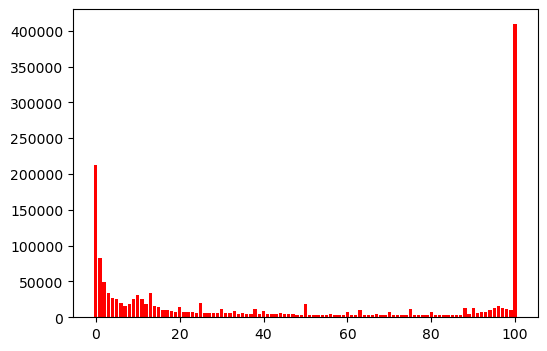

In [18]:
watch = interactions['watched_pct'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(watch.index, watch, color='red')
plt.show()

In [19]:
interactions[interactions['watched_pct']>90.0]

,user_id,item_id,last_watch_dt,total_dur,watched_pct
1,699317,1659,2021-05-29,8317.0,100.0
3,864613,7638,2021-07-05,14483.0,100.0
4,964868,9506,2021-04-30,6725.0,100.0
5,1032142,6686,2021-05-13,11286.0,100.0
9,203219,13582,2021-08-22,6975.0,100.0
...,...,...,...,...,...
1594773,25885,2237,2021-04-19,8871.0,100.0
1594775,334458,3669,2021-08-16,5968.0,98.0
1594776,776059,13865,2021-08-16,6284.0,99.0
1594782,63645,16373,2021-04-20,30964.0,100.0


In [20]:
print(interactions['last_watch_dt'].min(), interactions['last_watch_dt'].max())

20 2021-08-22


In [21]:
interactions['last_watch_dt'].unique()
interactions['last_watch_dt'] = pd.to_datetime(interactions['last_watch_dt'], format='%Y-%m-%d', errors='coerce')
interactions = interactions.dropna(subset=['last_watch_dt'])
interactions.isnull().sum()

user_id            0
item_id            0
last_watch_dt      0
total_dur          0
watched_pct      267
dtype: int64

In [22]:
print(interactions['last_watch_dt'].min(), interactions['last_watch_dt'].max())

2021-03-13 00:00:00 2021-08-22 00:00:00


In [23]:
monthly = interactions.groupby(pd.Grouper(key='last_watch_dt', freq='M')).agg({
    'user_id': 'count',
    'total_dur': 'sum'
}).rename(columns={'user_id': 'total_interactions'})
monthly

/var/folders/qs/gxy4f99x26l7w88l0zk12_w00000gn/T/ipykernel_1718/320462991.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = interactions.groupby(pd.Grouper(key='last_watch_dt', freq='M')).agg({


,total_interactions,total_dur
last_watch_dt,,
2021-03-31,77213,4.601695e+08
2021-04-30,149717,8.979473e+08
2021-05-31,221713,1.634697e+09
2021-06-30,348872,3.612364e+09
2021-07-31,427045,3.993559e+09
2021-08-31,370226,2.598928e+09


In [24]:
day = interactions.groupby(pd.Grouper(key='last_watch_dt', freq='D')).agg({
    'user_id': 'count',
    'total_dur': 'sum'
}).rename(columns={'user_id': 'total_interactions'})
day

,total_interactions,total_dur
last_watch_dt,,
2021-03-13,4701,29346483.0
2021-03-14,4494,29502382.0
2021-03-15,3768,25780151.0
2021-03-16,3767,23211596.0
2021-03-17,3793,24194580.0
...,...,...
2021-08-18,16478,110727107.0
2021-08-19,17155,119043076.0
2021-08-20,17521,116506997.0


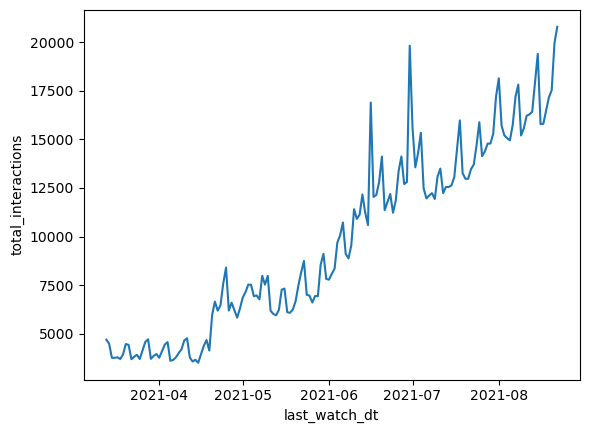

In [25]:
sns.lineplot(data=day, x='last_watch_dt', y='total_interactions');

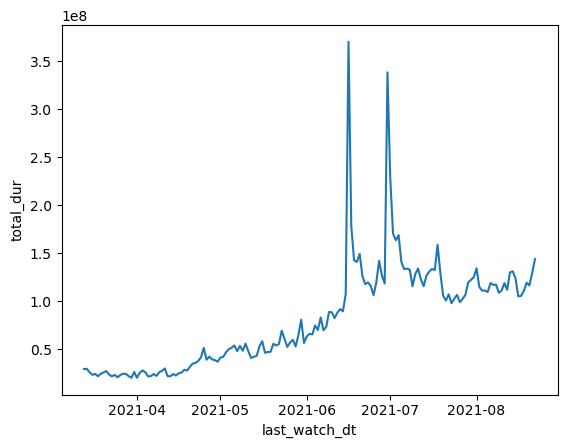

In [26]:
sns.lineplot(data=day, x='last_watch_dt', y='total_dur');

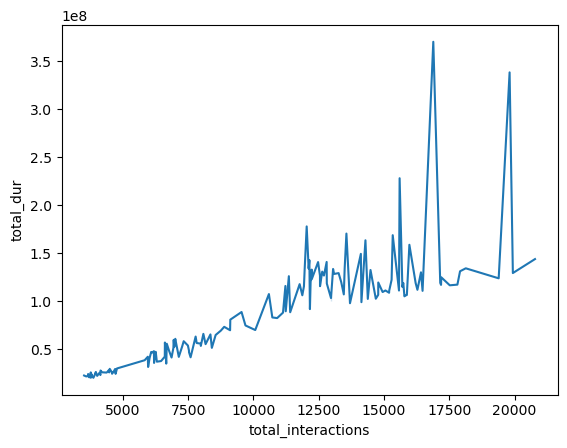

In [27]:
sns.lineplot(data=day, x='total_interactions', y='total_dur');

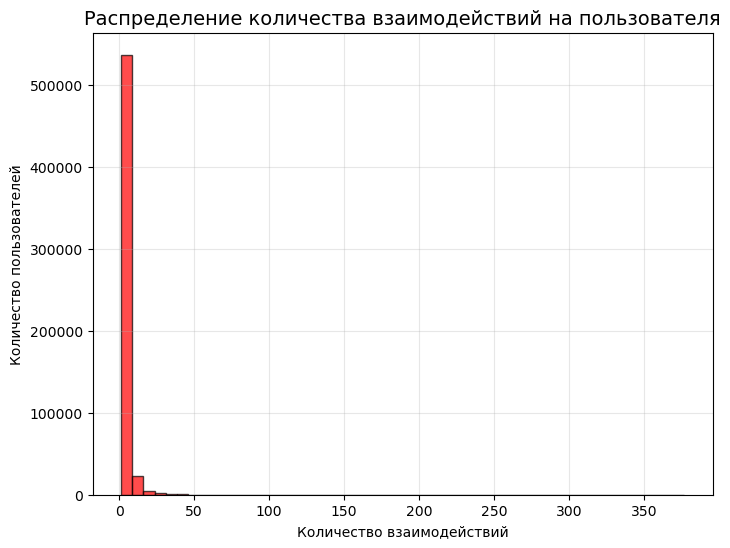

In [29]:
user_activity = interactions.groupby('user_id').size().reset_index(name='interactions_count')

plt.figure(figsize=(8, 6))
plt.hist(user_activity['interactions_count'], bins=50, alpha=0.7, color='red', edgecolor='black')
plt.title('Распределение количества взаимодействий на пользователя', fontsize=14)
plt.xlabel('Количество взаимодействий')
plt.ylabel('Количество пользователей')
plt.grid(alpha=0.3)
plt.show()

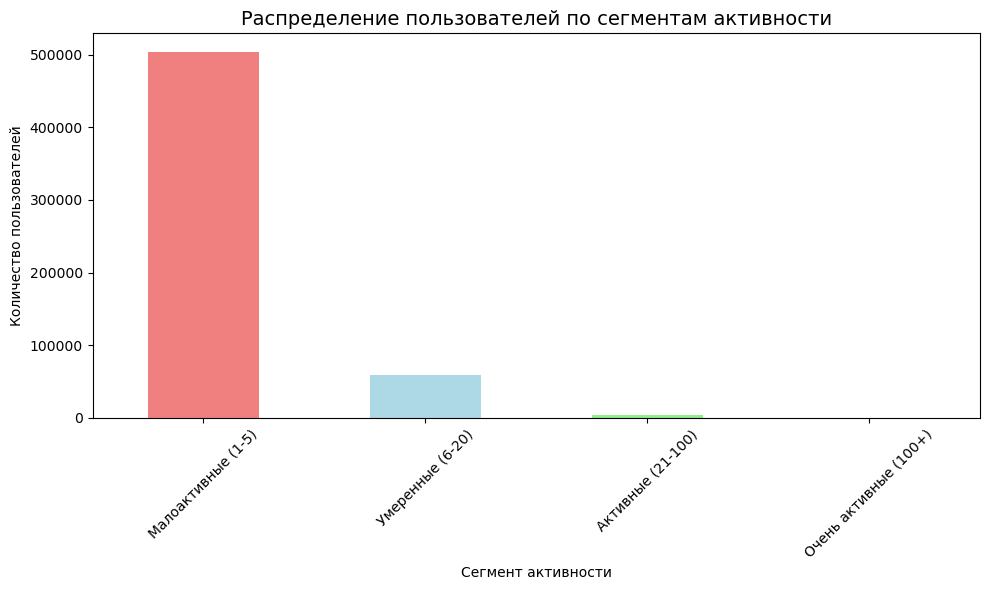


Распределение по сегментам активности:
activity_segment
Малоактивные (1-5)       504361
Умеренные (6-20)          58846
Активные (21-100)          4346
Очень активные (100+)        35
Name: count, dtype: int64


In [30]:
def categorize_activity(count):
    if 1 <= count <= 5:
        return 'Малоактивные (1-5)'
    elif 5 < count <= 20:
        return 'Умеренные (6-20)'
    elif 20 < count <= 100:
        return 'Активные (21-100)'
    else:
        return 'Очень активные (100+)'

user_activity['activity_segment'] = user_activity['interactions_count'].apply(categorize_activity)

segment_counts = user_activity['activity_segment'].value_counts()

plt.figure(figsize=(10, 6))
segment_counts.plot(kind='bar', color=['lightcoral', 'lightblue', 'lightgreen', 'gold'])
plt.title('Распределение пользователей по сегментам активности', fontsize=14)
plt.xlabel('Сегмент активности')
plt.ylabel('Количество пользователей')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nРаспределение по сегментам активности:")
print(segment_counts)

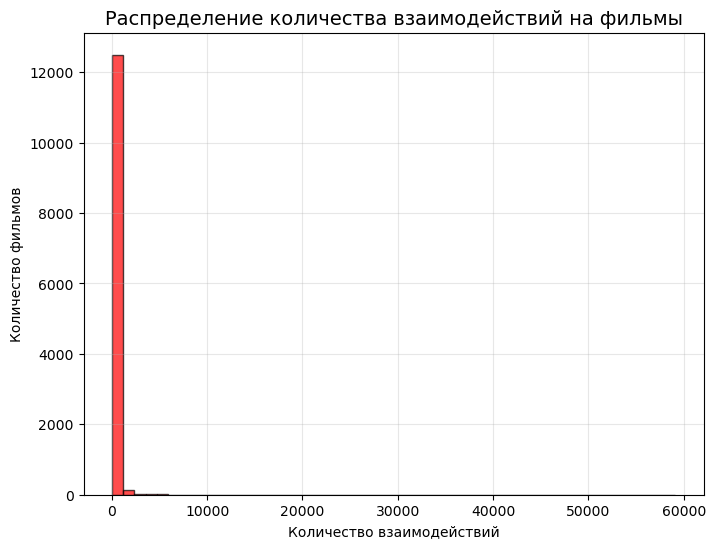

In [31]:
item_activity = interactions.groupby('item_id').size().reset_index(name='interactions_count')

plt.figure(figsize=(8, 6))
plt.hist(item_activity['interactions_count'], bins=50, alpha=0.7, color='red', edgecolor='black')
plt.title('Распределение количества взаимодействий на фильмы', fontsize=14)
plt.xlabel('Количество взаимодействий')
plt.ylabel('Количество фильмов')
plt.grid(alpha=0.3)
plt.show()

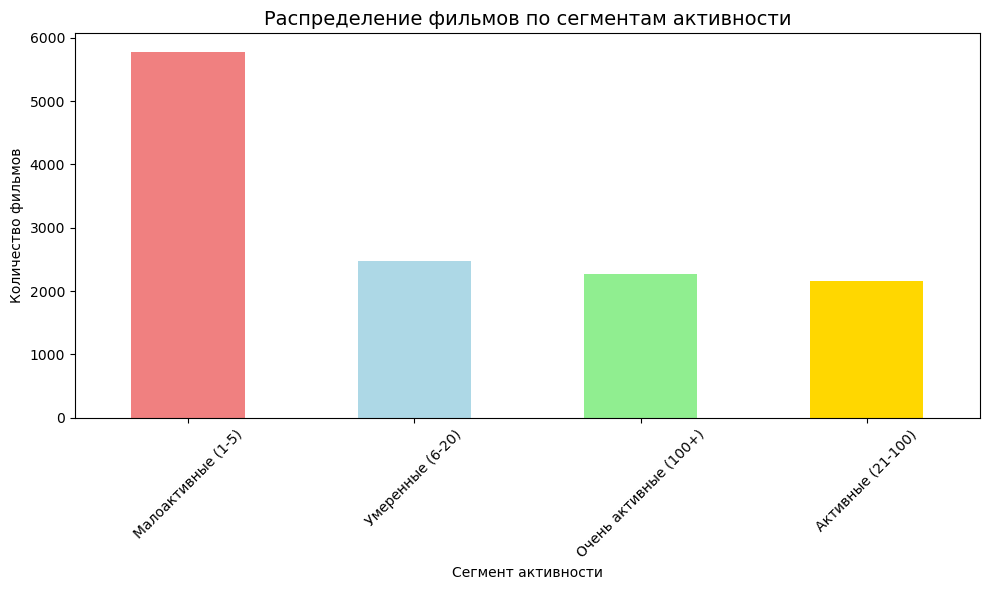


Распределение по сегментам активности:
activity_segment
Малоактивные (1-5)       5782
Умеренные (6-20)         2468
Очень активные (100+)    2276
Активные (21-100)        2167
Name: count, dtype: int64


In [32]:
def categorize_activity(count):
    if 1 <= count <= 5:
        return 'Малоактивные (1-5)'
    elif 5 < count <= 20:
        return 'Умеренные (6-20)'
    elif 20 < count <= 100:
        return 'Активные (21-100)'
    else:
        return 'Очень активные (100+)'

item_activity['activity_segment'] = item_activity['interactions_count'].apply(categorize_activity)

segment_counts_item = item_activity['activity_segment'].value_counts()

plt.figure(figsize=(10, 6))
segment_counts_item.plot(kind='bar', color=['lightcoral', 'lightblue', 'lightgreen', 'gold'])
plt.title('Распределение фильмов по сегментам активности', fontsize=14)
plt.xlabel('Сегмент активности')
plt.ylabel('Количество фильмов')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nРаспределение по сегментам активности:")
print(segment_counts_item)

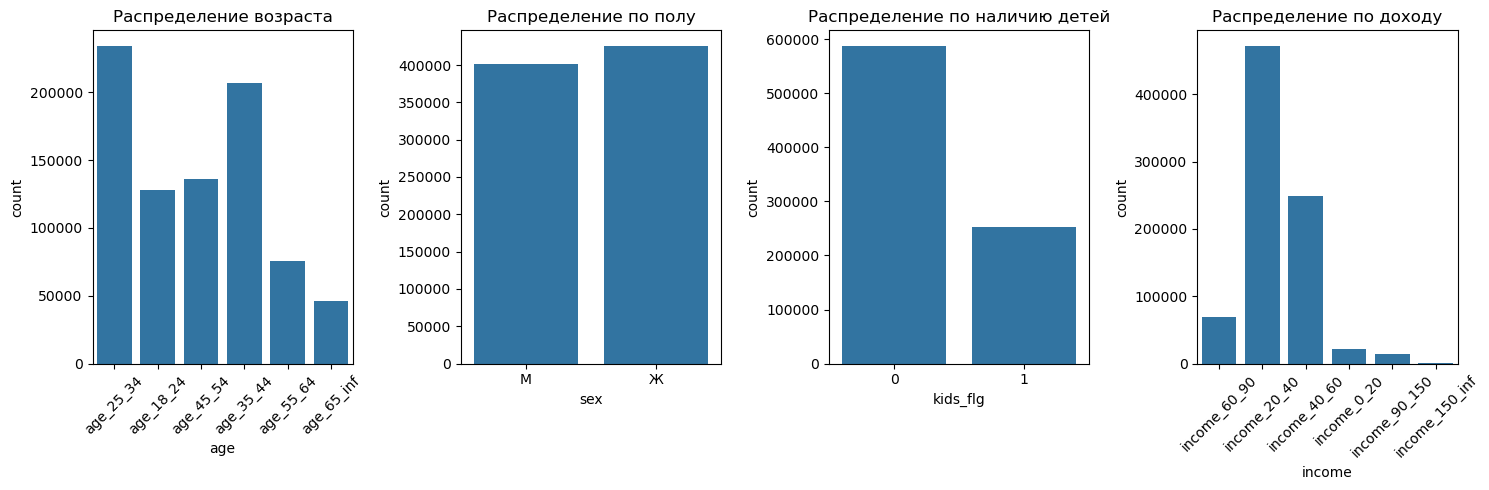

In [33]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.xticks(rotation=45)
sns.countplot(x=users['age'])
plt.title('Распределение возраста')

plt.subplot(1, 4, 2)
sns.countplot(x=users['sex'])
plt.title('Распределение по полу')

plt.subplot(1, 4, 3)
sns.countplot(x=users['kids_flg'])
plt.title('Распределение по наличию детей')

plt.subplot(1, 4, 4)
plt.xticks(rotation=45)
sns.countplot(x=users['income'])
plt.title('Распределение по доходу')

plt.tight_layout()
plt.show()

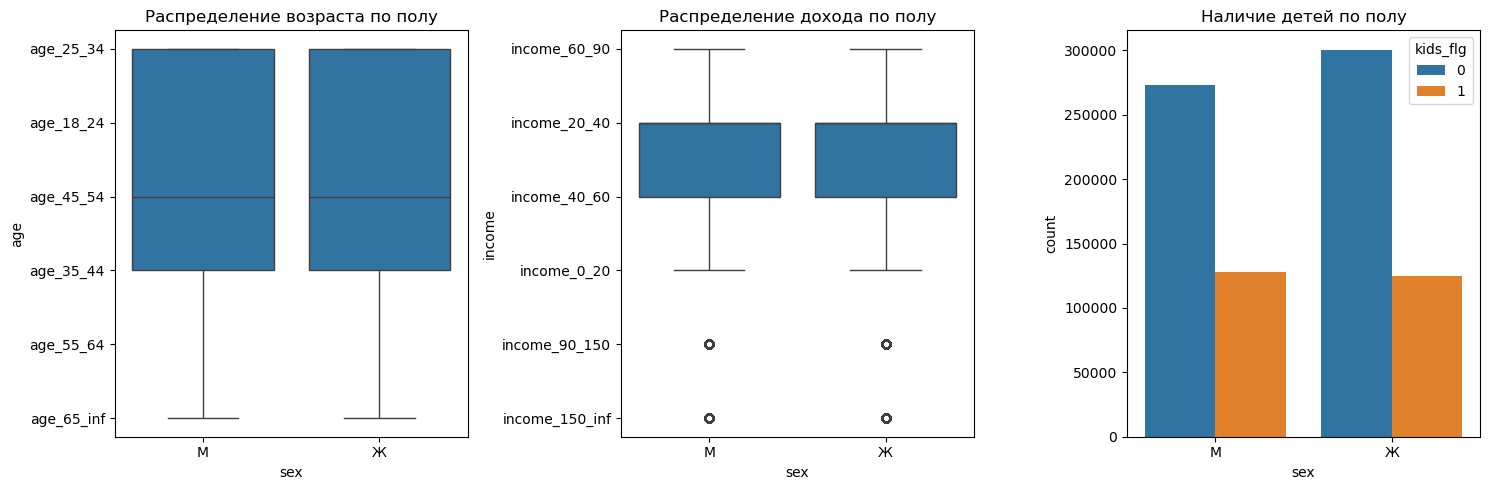

In [34]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(data=users, x='sex', y='age')
plt.title('Распределение возраста по полу')

plt.subplot(1, 3, 2)
sns.boxplot(data=users, x='sex', y='income')
plt.title('Распределение дохода по полу')

plt.subplot(1, 3, 3)
sns.countplot(data=users, x=users['sex'], hue=users['kids_flg'])
plt.title('Наличие детей по полу')

plt.tight_layout()
plt.show()


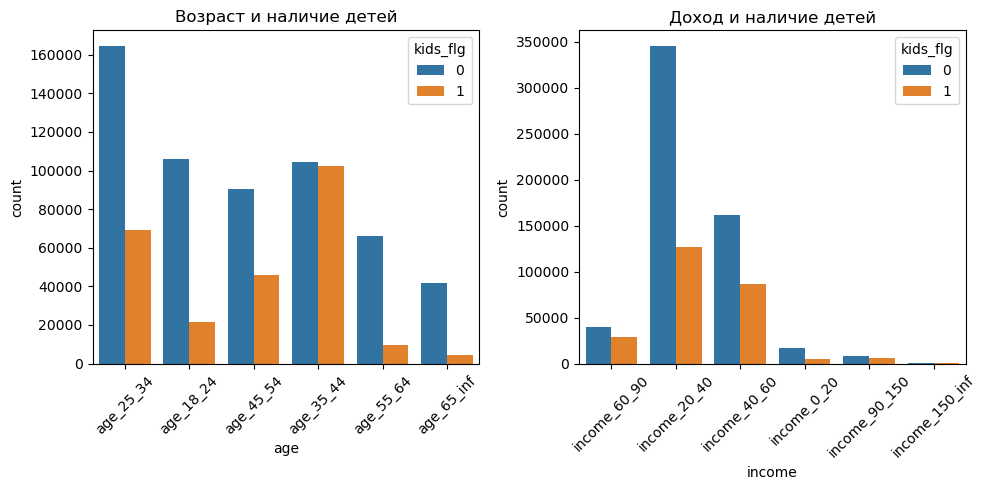

In [35]:
plt.figure(figsize=(10, 5))


plt.subplot(1, 2, 1)
plt.xticks(rotation=45)
sns.countplot(data=users, x='age', hue='kids_flg')
plt.title('Возраст и наличие детей')

plt.subplot(1, 2, 2)
plt.xticks(rotation=45)
sns.countplot(data=users, x='income', hue='kids_flg')
plt.title('Доход и наличие детей')

plt.tight_layout()
plt.show()

In [36]:
items.head()

,item_id,content_type,title,title_orig,release_year,genres,countries,for_kids,age_rating,studios,directors,actors,description,keywords
0,10711,film,Поговори с ней,Hable con ella,2002.0,"драмы, зарубежные, детективы, мелодрамы",Испания,NaN,16.0,NaN,Педро Альмодовар,"Адольфо Фернандес, Ана Фернандес, Дарио Гранди...",Мелодрама легендарного Педро Альмодовара «Пого...,"Поговори, ней, 2002, Испания, друзья, любовь, ..."
1,2508,film,Голые перцы,Search Party,2014.0,"зарубежные, приключения, комедии",США,NaN,16.0,NaN,Скот Армстронг,"Адам Палли, Брайан Хаски, Дж.Б. Смув, Джейсон ...",Уморительная современная комедия на популярную...,"Голые, перцы, 2014, США, друзья, свадьбы, прео..."
2,10716,film,Тактическая сила,Tactical Force,2011.0,"криминал, зарубежные, триллеры, боевики, комедии",Канада,NaN,16.0,NaN,Адам П. Калтраро,"Адриан Холмс, Даррен Шалави, Джерри Вассерман,...",Профессиональный рестлер Стив Остин («Все или ...,"Тактическая, сила, 2011, Канада, бандиты, ганг..."
3,7868,film,45 лет,45 Years,2015.0,"драмы, зарубежные, мелодрамы",Великобритания,NaN,16.0,NaN,Эндрю Хэй,"Александра Риддлстон-Барретт, Джеральдин Джейм...","Шарлотта Рэмплинг, Том Кортни, Джеральдин Джей...","45, лет, 2015, Великобритания, брак, жизнь, лю..."
4,16268,film,Все решает мгновение,NaN,1978.0,"драмы, спорт, советские, мелодрамы",СССР,NaN,12.0,Ленфильм,Виктор Садовский,"Александр Абдулов, Александр Демьяненко, Алекс...",Расчетливая чаровница из советского кинохита «...,"Все, решает, мгновение, 1978, СССР, сильные, ж..."


In [37]:
items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15963 entries, 0 to 15962
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   item_id       15963 non-null  int64  
 1   content_type  15963 non-null  object 
 2   title         15963 non-null  object 
 3   title_orig    11218 non-null  object 
 4   release_year  15865 non-null  float64
 5   genres        15963 non-null  object 
 6   countries     15926 non-null  object 
 7   for_kids      566 non-null    float64
 8   age_rating    15961 non-null  float64
 9   studios       1065 non-null   object 
 10  directors     14454 non-null  object 
 11  actors        13344 non-null  object 
 12  description   15961 non-null  object 
 13  keywords      15540 non-null  object 
dtypes: float64(3), int64(1), object(10)
memory usage: 1.7+ MB


In [38]:
items.isnull().sum()


item_id             0
content_type        0
title               0
title_orig       4745
release_year       98
genres              0
countries          37
for_kids        15397
age_rating          2
studios         14898
directors        1509
actors           2619
description         2
keywords          423
dtype: int64

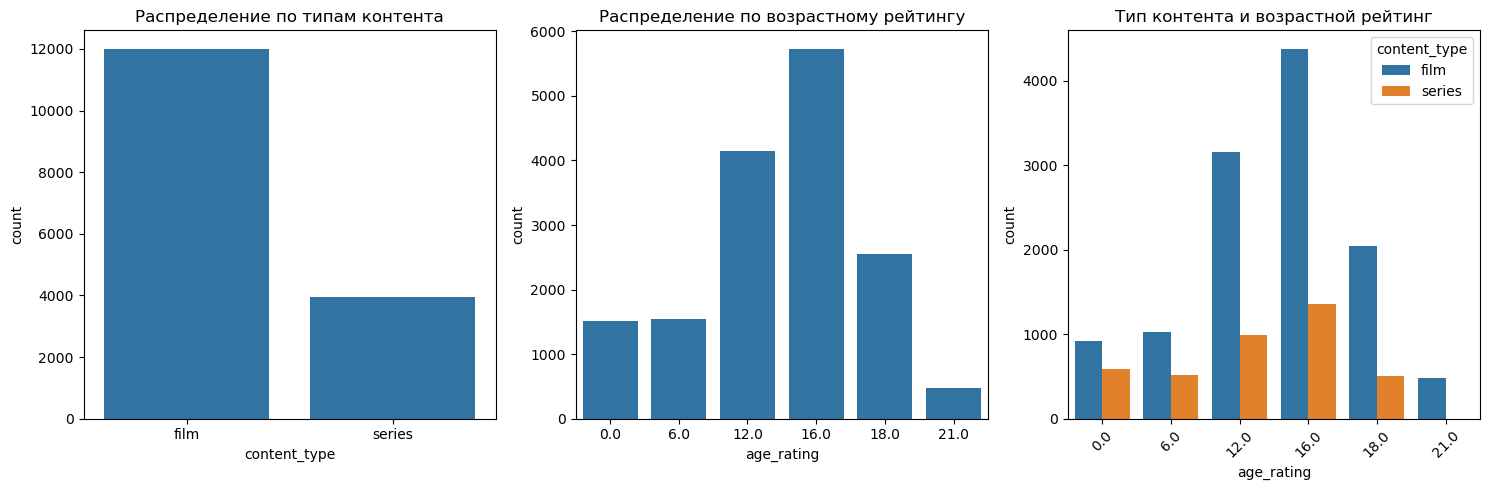

In [39]:
plt.figure(figsize=(15, 5))


plt.subplot(1, 3, 1)
sns.countplot(data=items, x='content_type')
plt.title('Распределение по типам контента')

plt.subplot(1, 3, 2)
sns.countplot(data=items, x='age_rating')
plt.title('Распределение по возрастному рейтингу')

plt.subplot(1, 3, 3)
plt.xticks(rotation=45)
sns.countplot(data=items, x='age_rating', hue='content_type')
plt.title('Тип контента и возрастной рейтинг')

plt.tight_layout()
plt.show()

count    15865.000000
mean      2007.932241
std         16.881118
min       1897.000000
25%       2007.000000
50%       2014.000000
75%       2018.000000
max       2021.000000
Name: release_year, dtype: float64


Text(0, 0.5, 'Количество')

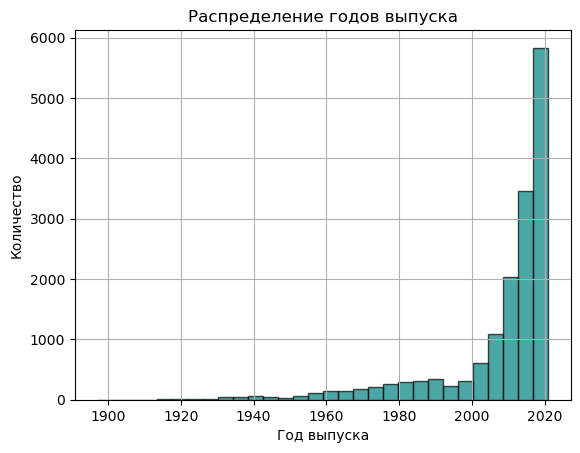

In [40]:
print(items['release_year'].describe())

items['release_year'].hist(bins=30, alpha=0.7, color='teal', edgecolor='black')
plt.title('Распределение годов выпуска')
plt.xlabel('Год выпуска')
plt.ylabel('Количество')

Всего уникальных жанров: 95


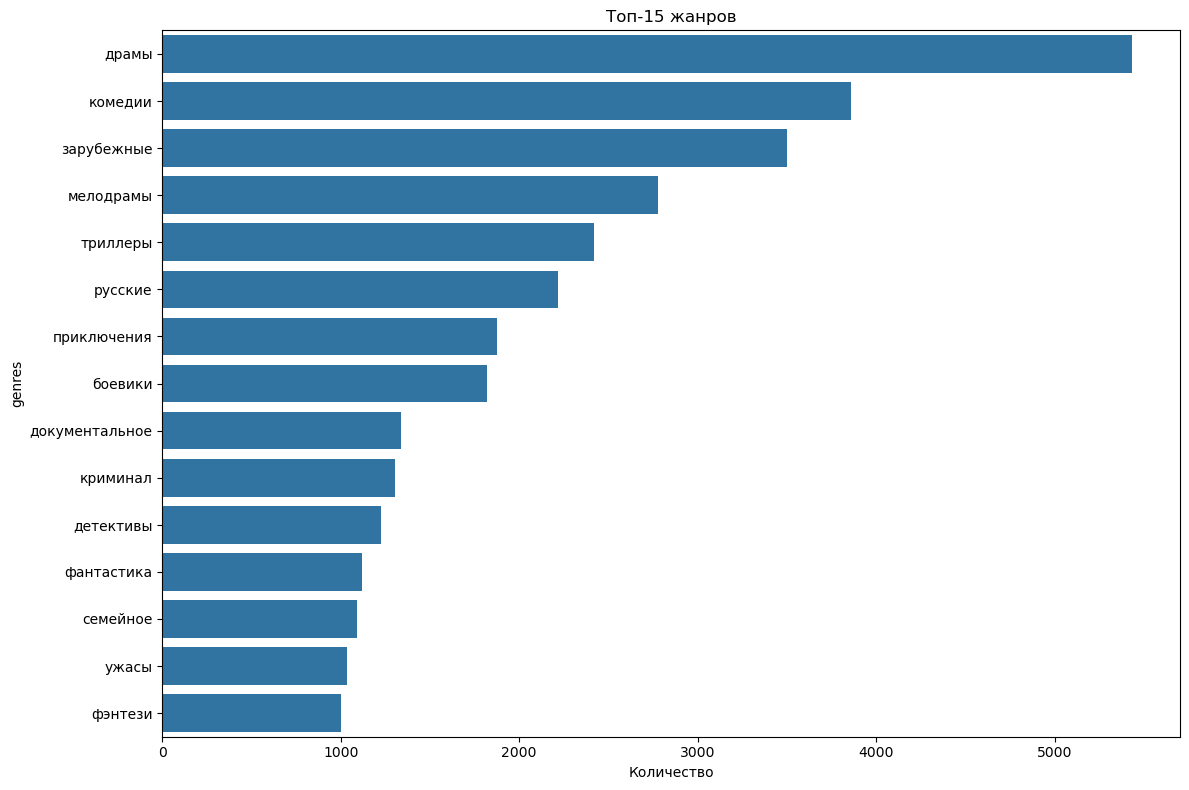


Среднее количество жанров на элемент: 2.55
Максимальное количество жанров: 9


In [41]:
if items['genres'].notna().any():
    all_genres = items['genres'].str.split(',').explode().str.strip()
    genre_counts = all_genres.value_counts()
    
    print(f"Всего уникальных жанров: {len(genre_counts)}")
    
    plt.figure(figsize=(12, 8))
    top_genres = genre_counts.head(15)
    sns.barplot(x=top_genres.values, y=top_genres.index)
    plt.title('Топ-15 жанров')
    plt.xlabel('Количество')
    plt.tight_layout()
    plt.show()
    
    items['genre_count'] = items['genres'].str.split(',').apply(lambda x: len(x) if isinstance(x, list) else 0)
    print(f"\nСреднее количество жанров на элемент: {items['genre_count'].mean():.2f}")
    print(f"Максимальное количество жанров: {items['genre_count'].max()}")

Всего уникальных стран: 91


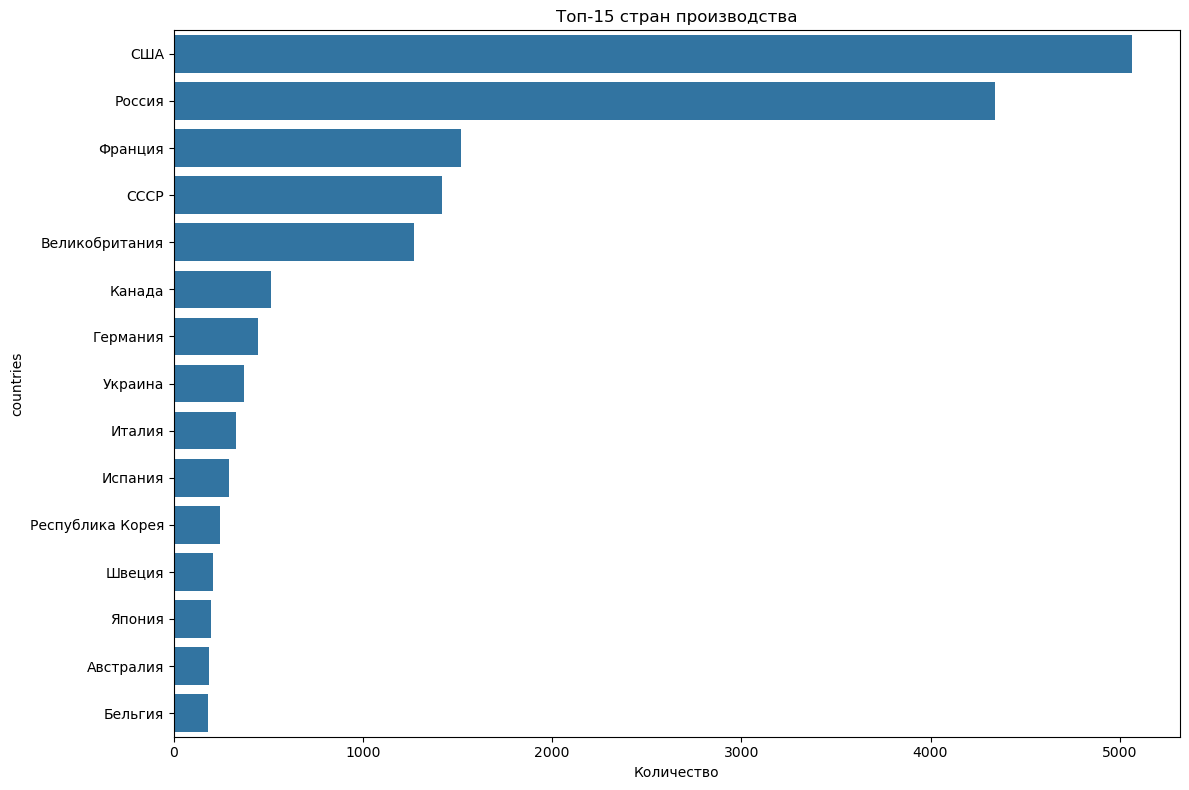

In [42]:
if items['countries'].notna().any():
    all_countries = items['countries'].str.split(',').explode().str.strip()
    country_counts = all_countries.value_counts()
    
    print(f"Всего уникальных стран: {len(country_counts)}")
    
    plt.figure(figsize=(12, 8))
    top_countries = country_counts.head(15)
    sns.barplot(x=top_countries.values, y=top_countries.index)
    plt.title('Топ-15 стран производства')
    plt.xlabel('Количество')
    plt.tight_layout()
    plt.show()

Всего уникальных студий: 32


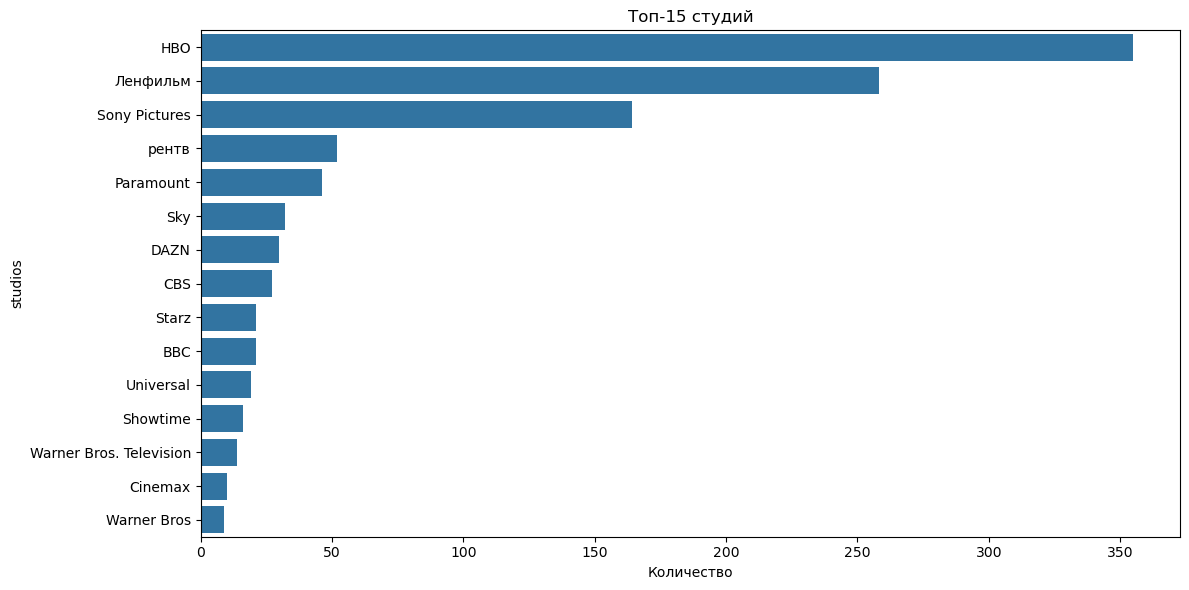

In [43]:
if items['studios'].notna().any():
    all_studios = items['studios'].str.split(',').explode().str.strip()
    studio_counts = all_studios.value_counts()
    
    print(f"Всего уникальных студий: {len(studio_counts)}")
    
    plt.figure(figsize=(12, 6))
    top_studios = studio_counts.head(15)
    sns.barplot(x=top_studios.values, y=top_studios.index)
    plt.title('Топ-15 студий')
    plt.xlabel('Количество')
    plt.tight_layout()
    plt.show()

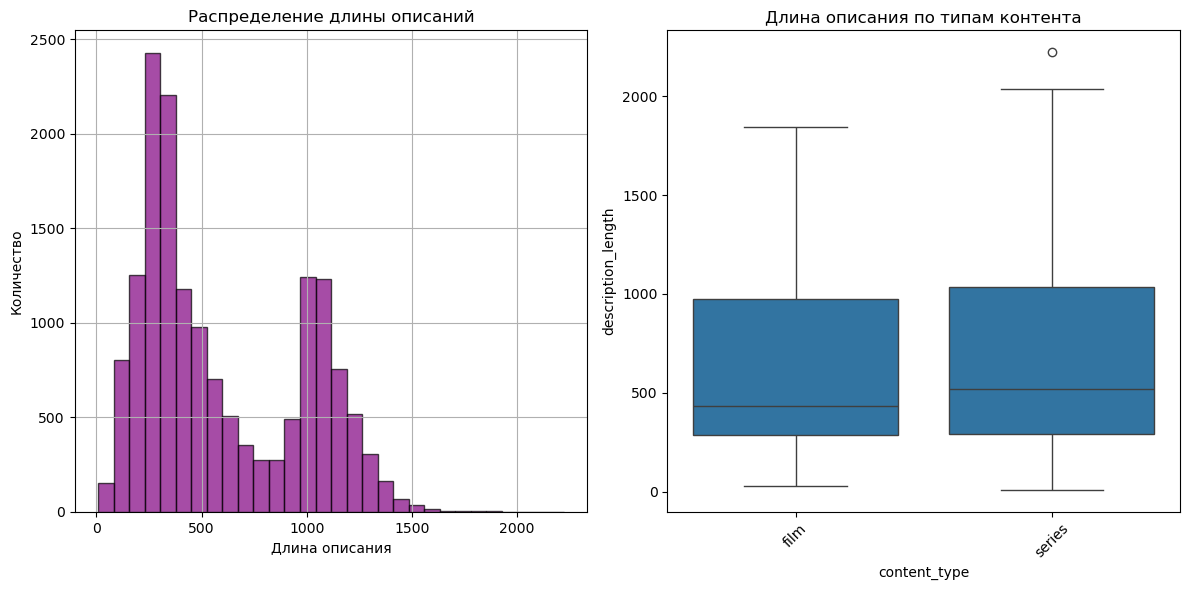

Средняя длина описания: 595.5 символов
Медианная длина описания: 448.0 символов


In [44]:
if 'description' in items.columns:
    items['description_length'] = items['description'].str.len()
    
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    items['description_length'].hist(bins=30, alpha=0.7, color='purple', edgecolor='black')
    plt.title('Распределение длины описаний')
    plt.xlabel('Длина описания')
    plt.ylabel('Количество')
    
    plt.subplot(1, 2, 2)
    sns.boxplot(data=items, x='content_type', y='description_length')
    plt.title('Длина описания по типам контента')
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Средняя длина описания: {items['description_length'].mean():.1f} символов")
    print(f"Медианная длина описания: {items['description_length'].median():.1f} символов")

Всего уникальных ключевых слов: 43681

Топ-20 ключевых слов:
keywords
отношения            9208
Россия               3294
соединенные штаты    2844
женщины              2714
любовь               2639
мужчины              2250
преодоление          2104
трудностей           2102
США                  2093
борьба               1897
дружба               1765
2020                 1673
убийцы               1487
дети                 1425
друзья               1369
за                   1319
СССР                 1302
2019                 1278
2018                 1215
франция              1183
Name: count, dtype: int64


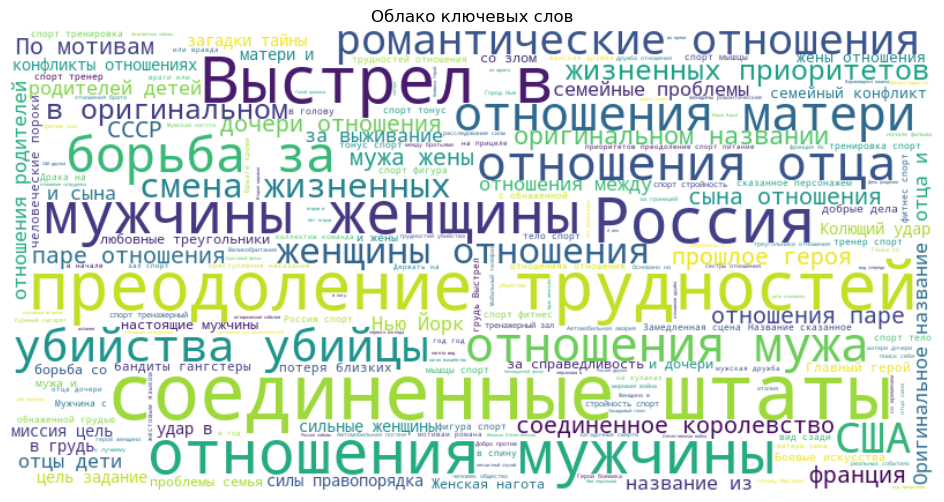

In [45]:
if 'keywords' in items.columns and items['keywords'].notna().any():
    all_keywords = items['keywords'].str.split(',').explode().str.strip()
    keyword_counts = all_keywords.value_counts()
    
    print(f"Всего уникальных ключевых слов: {len(keyword_counts)}")
    print("\nТоп-20 ключевых слов:")
    print(keyword_counts.head(20))

    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(all_keywords.dropna()))
    
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Облако ключевых слов')
    plt.show()